## `make_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `results_methods.py`

In [72]:
import numpy as np 
import fitsio as fio
import pandas as pd 
import importlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.optimize import minimize_scalar
from functools import partial
from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from pathlib import Path
from pycorr import TwoPointEstimator
from scipy.integrate import simpson
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.calibration as cal

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [44]:
importlib.reload(inference)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT / 'v1' / f'autos_NGC', #quasar spacing bla bla bla
    'DESI_NGC' : ROOT / 'v1' / f'autos_NGC',
    'DESI_SGC' : None,
    'DESIxHSC' : ROOT / 'v1' / f'cross',
}
for v in path_dictionary.values():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."

In [4]:
## get sigmaj corrections
sims = False
if sims:
    catalog = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/sims/v5/hscy3_sim_v5.fits')[1]
    zcat = catalog['Z'].read()
else:
    catalog = fio.FITS('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits')[1]
    zcat = catalog['dnnz_photoz_best'].read()

/tmp/ipykernel_1966387/2779201722.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


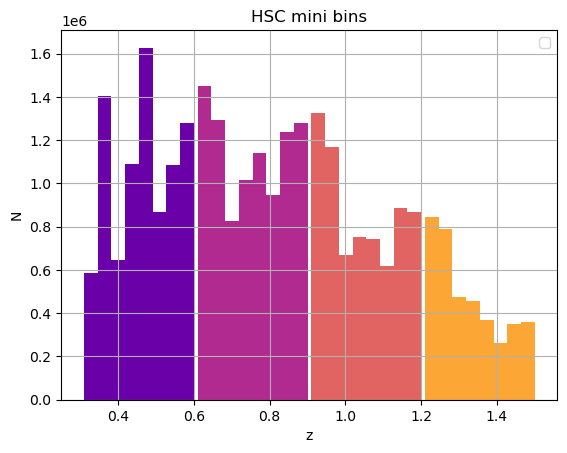

In [27]:
# hsc mini bins
mini_hsc = cf.CorrFileReader(path_dictionary['HSC']).get_bins('HSC')
colormap = plt.get_cmap('plasma')
# get sigmaj for two adjacents bins (std of redshift distribution in the bin ...)
sigmaj_corr = []
zmid = []
for i in range(1, len(mini_hsc)):
    z_bin = zcat[(zcat > mini_hsc[i-1]) & (zcat <= mini_hsc[i])]
    zmid.append(np.mean(z_bin))
    # careful : it's 1/std of the redshift distribution in the bin
    sigmaj_corr.append(np.std(z_bin))
    plt.hist(
        z_bin, 
        bins=int(40/len(mini_hsc)), 
        color=colormap(i/len(mini_hsc)),
        )
plt.xlabel('z')
plt.ylabel('N')
plt.title('HSC mini bins')
plt.grid()
plt.legend()

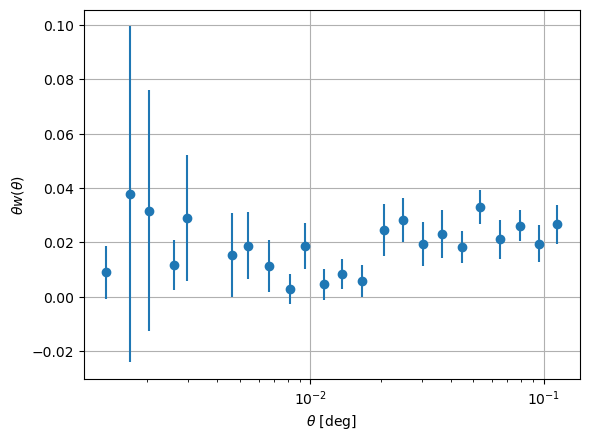

In [45]:
file = cf.CorrFileReader(path_dictionary['DESI_NGC']).get_file(2, 2, 'QSO', 'QSO', moc=1)
tpcf = TwoPointEstimator.load(file)
tpcf.plot()
plt.xscale('log')

In [56]:
importlib.reload(inference)
importlib.reload(comb)
tracer = 'QSO'
nz = []
nz_err = []
for i in range(1, 5):
    kwargs = {
        'path_dictionary' : path_dictionary,
        'scale_cuts' : [1, 5.0],
        'tracer' : tracer,
        'tomo_bin' : i,
        'sigmaj_corrections' : np.ones_like(sigmaj_corr),
        'verbose' : True,
    }
    print(f"Computing n(z) for tracer {tracer} and tomo bin {i}")
    nz_nz_err = inference.full_npz_tomo(
            **kwargs
            )
    nz.append(nz_nz_err[0][:-5])
    nz_err.append(nz_nz_err[1][:-5])

Computing n(z) for tracer QSO and tomo bin 1
Computing n(z) for tracer QSO and tomo bin 2
Computing n(z) for tracer QSO and tomo bin 3
Computing n(z) for tracer QSO and tomo bin 4


In [57]:
nz

[array([-0.02395156,  0.00507109,  0.00357261, -0.01011524, -0.00257989,
        -0.01347752, -0.01821996,  0.00217662,  0.00934479, -0.00547089,
        -0.01456763, -0.00562661, -0.00723806,  0.00631688,  0.00270521,
        -0.01466732, -0.01097733, -0.00242924, -0.00816976, -0.0156175 ,
        -0.01719499, -0.00036414, -0.01805636, -0.01518975, -0.00295882,
        -0.00393139, -0.00346395, -0.00861363, -0.01635313,  0.00127088,
        -0.01458407, -0.01286427, -0.01633751, -0.0119088 ,  0.00071708]),
 array([ 0.08017266,  0.07616629,  0.04930564,  0.00898848,  0.01491456,
         0.01842009,  0.00210964,  0.01489611, -0.00344284, -0.01593187,
        -0.00764625, -0.00150022,  0.00122248,  0.01250666, -0.00013317,
        -0.02350325, -0.01076718,  0.00887345, -0.00486297,  0.00962152,
        -0.00927118,  0.00765119, -0.01977905,  0.00341445,  0.00664412,
        -0.00184963,  0.01336221, -0.00527845, -0.00477484, -0.0083548 ,
        -0.00923183, -0.00331584,  0.01198582, -0

[0.82539681 0.8756424  0.9254198  0.97516194 1.02543879 1.07518749
 1.12549669 1.17521281 1.22527345 1.27517891 1.32506463 1.37498791
 1.42526383 1.47505349 1.52495182 1.5746221  1.6252795  1.67494221
 1.72497234 1.77486645 1.82509571 1.87494062 1.92493532 1.97462464
 2.02481699 2.07461536 2.12479249 2.17468277 2.22478617 2.27458542
 2.32428116 2.37484388 2.42475867 2.47460937 2.52488907]


(-2.0, 5.0)

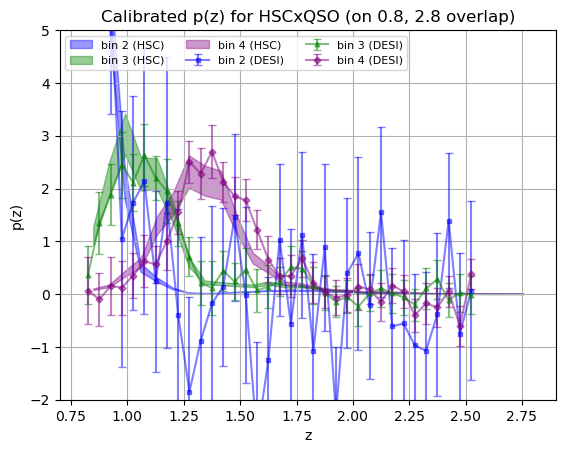

In [58]:
fr_corr = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    )
bins_hsc = np.arange(0.3, 1.8, 0.3)
colors = ['red', 'blue', 'green', 'purple']
markers = ['x', 's', '^', 'D']
zval = fr_corr.get_zeff(tracer, tracer)[:-5]
bins_tracer = fr_corr.get_bins(tracer)
print(zval)

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
mids = tomo_bin_dnnz[mask, 0]

dnnz_list = []
mu_list = []
cov_list = []
ids_to_skip = []
range_tracer = [bins_tracer[0], bins_tracer[-1]]

for i in range(4):
    if max(range_tracer[0], bins_hsc[i]) > min(range_tracer[1], bins_hsc[i+1]):
        ids_to_skip.append(i)
ncurves = 0
for i in range(4):
    if i in ids_to_skip:
        #pass
        continue
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[mask, i+1], mids)

    plt.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colors[i], 
        label=f'bin {i+1} (HSC)',
        alpha=0.4
        )
    normalization = simpson(nz[i], x=zval)
    plt.errorbar(
        zval, 
        nz[i]/normalization, 
        nz_err[i]/normalization,
        marker=markers[i], 
        markersize=3.5, 
        linestyle='-',  
        alpha=0.5,
        color=colors[i],
        label=f'bin {i+1} (DESI)',
        capsize=3,
        )
    
plt.xlabel('z')
plt.ylabel('p(z)')
plt.grid()
plt.legend(fontsize=8, ncols=ncurves, loc='upper left')
plt.title(f'Calibrated p(z) for HSCx{tracer} (on {min(bins_tracer):.1f}, {max(bins_tracer):.1f} overlap)')
plt.xlim(min(bins_tracer)-0.1, max(bins_tracer)+0.1)
plt.ylim(-2, 5)

In [ ]:
importlib.reload(inference)
data = []
# wsp_meas, wpp_meas, wss_meas, hsc_bias, desi_bias, deltaz, zloc, result
for i in range(1, 5):
    print(f"Computing n(z) for tracer {tracer} and tomo bin {i}")
    data.append(
        inference.full_npz_tomo(
            path_dictionary=path_dictionary,
            scale_cuts=[1, 5.0],
            tracer=tracer,
            tomo_bin=i,
            verbose=True,
            return_chunks=True,
            sigmaj_corrections=np.ones_like(sigmaj_corr),
        )
    )

Computing n(z) for tracer QSO and tomo bin 1
Computing n(z) for tracer QSO and tomo bin 2
Computing n(z) for tracer QSO and tomo bin 3
Computing n(z) for tracer QSO and tomo bin 4


Text(0, 0.5, 'w')

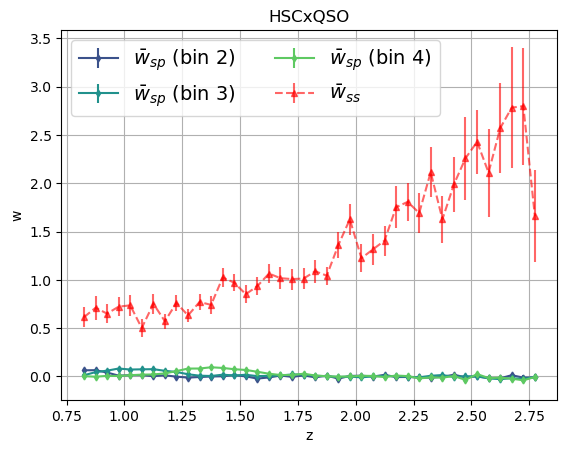

In [61]:
zval = fr_corr.get_zeff(tracer, tracer)
cmap = plt.get_cmap('viridis')
for i in range(4):
    if i in ids_to_skip:
        #pass
        continue
    plt.errorbar(
        zval, 
        data[i][:, 0], 
        data[i][:, 1],
        label=r'$\bar{w}_{sp}$' + f' (bin {i+1})', 
        color=cmap(i/4),
        marker='d',
        markersize=3.5,
        )
if False:
    plt.errorbar(
        zval, 
        data[i][:, 2], 
        data[i][:, 3],
        label=r'$\bar{w}_{pp}$', 
        color='black', 
        alpha=0.6, 
        linestyle='-.', 
        marker='x', 
        markersize=4
        ) 
plt.errorbar(
    zval, 
    data[i][:, 4], 
    data[i][:, 5],
    label=r'$\bar{w}_{ss}$', 
    color='red', 
    alpha=0.6, 
    linestyle='--', 
    markersize=4, 
    marker='^'
    )

plt.grid()
plt.legend(loc='upper left', fontsize=14, ncol=2)
plt.title(f'HSCx{tracer}')
plt.xlabel('z')
plt.ylabel('w')

Text(0.5, 1.0, 'Bias models as a function of redshift for tracers')

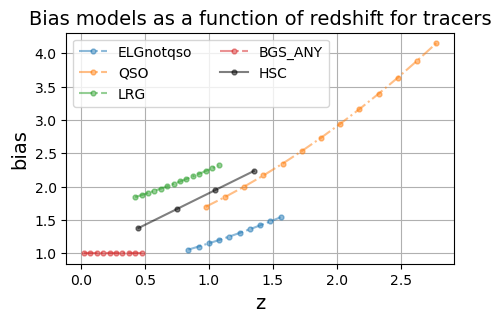

In [12]:
# plot the bias used
importlib.reload(inference)
plt.figure(figsize=(5, 3))
for tracer in ['ELGnotqso', 'QSO', 'LRG', 'BGS_ANY']:
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
    ).get_bins(tracer)
    mids_tracer = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    bias = inference.desi_bias_evolution(z=mids_tracer, tracer=tracer)
    plt.plot(
        mids_tracer, 
        bias, 
        marker='o', 
        markersize=3.5, 
        linestyle='-.',  
        alpha=0.5,
        label=f'{tracer}'
    )
mids_hsc = bins_hsc[:-1] + np.diff(bins_hsc) / 2
plt.plot(
    mids_hsc,
    inference.hsc_bias_evolution(z=mids_hsc, b=0.95),
    marker='o',
    markersize=3.5,
    linestyle='-',
    alpha=0.5,
    label='HSC',
    color='black'
)
plt.xlabel('z', fontsize=14)
plt.ylabel('bias', fontsize=14)
plt.grid()
plt.legend(ncols=2, loc='upper left', fontsize=10)
plt.title(f'Bias models as a function of redshift for tracers',  fontsize=14)

### Passive evolution fitting power law

In [13]:
## find the fit to the HSC passive evolution power law
importlib.reload(inference)
hsc_fine_path = ROOT / 'autos_hsc_0_1'
fr = cf.CorrFileReader(hsc_fine_path)
bins_fine_hsc = fr.get_bins('HSC')
wpp = []
wpp_err = []
sc_hsc = [0.2, 3]

for b in range(1, len(bins_fine_hsc)):
    meas = inference.wpp(hsc_fine_path, b, scale_cuts=sc_hsc)
    wpp.append(meas[0])
    wpp_err.append(meas[1])

zfine_hsc = bins_fine_hsc[:-1] + np.diff(bins_fine_hsc) / 2

#wpp = wpp[3:]
#wpp_err = wpp_err[3:]
#zfine_hsc = zfine_hsc[3:]

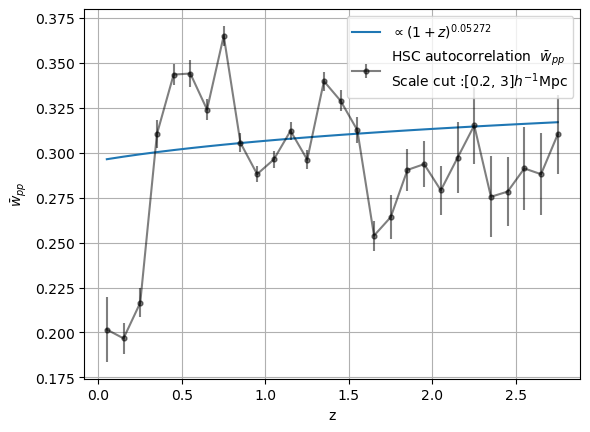

In [ ]:
def power_law(z, gamma, a):
    return a * (1 + z) ** gamma

popt, pcov = curve_fit(
    power_law,
    zfine_hsc,
    wpp,
    sigma=wpp_err,
    absolute_sigma=True
)
gamma_fit = popt[0]
a_fit = popt[1]
gamma_uncertainty = np.sqrt(np.diag(pcov))[0]

ev_fit = power_law(zfine_hsc, gamma_fit, a_fit)
plt.plot(
    zfine_hsc, 
    ev_fit, 
    label=rf'$\propto (1+z)^{{{gamma_fit:.5f}}}$'
    )

plt.errorbar(
    zfine_hsc, 
    wpp, 
    wpp_err,
    marker='o', 
    markersize=3.5, 
    linestyle='-',  
    alpha=0.5,
    label='HSC autocorrelation ' + r' $\bar{w}_{pp}$' + f'\nScale cut :' + f'[{sc_hsc[0]}, {sc_hsc[1]}]' + r'$h^{-1} \mathrm{Mpc}$',
    color='black'
)
plt.xlabel('z')
plt.ylabel(r'$\bar{w}_{pp}$')
plt.grid()
plt.legend()

In [ ]:
importlib.reload(inference)
scale_cuts = [[0.2, 1], [0.5, 2.5], [1, 5], [2, 10]]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
fig.subplots_adjust(right=0.85) 
axs = axs.flatten()

for n in range(len(tracers)):
    t = tracers[n]
    ax = axs[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    for k, sc in enumerate(scale_cuts):

        ids_to_skip = []
        nz = []

        for tomo in range(1, 5):
            print(f"Computing n(z) for tracer {t} and tomo bin {tomo}")
            nz.append(
                inference.full_npz_tomo(
                    path_dictionary=path_dictionary,
                    scale_cuts=sc,
                    tracer=t,
                    tomo_bin=tomo,
                    sigmaj_corrections=np.ones_like(sigmaj_corr),
                    rebin=2,
                    )
            )

        for j in range(4):
            if max(range_tracer[0], bins_hsc[j]) > min(range_tracer[1], bins_hsc[j+1]):
                ids_to_skip.append(j)
                continue
            ncurves = 0
            ax.plot(
                zval, 
                nz[j]/simpson(nz[j], x=zval), 
                marker=markers[j], 
                linestyle=linestyles[j],
                markersize=3.5,   
                alpha=0.8,
                color=colormaps[j]((k+1)/4),
                )

    for m in range(4):
        if m not in ids_to_skip:
            ncurves += 1

            dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[mask, m+1], mids)

            ax.fill_between(
                mids, 
                np.percentile(dnnz, 16, axis=0), 
                np.percentile(dnnz, 84, axis=0), 
                color=colormaps[m]((m+2)/5), 
                label=f'bin {m+1} (DNNz)',
                alpha=0.4
                )
    if n == 2 or n == 3: 
        ax.set_xlabel('z')
    if n == 0 or n == 2:
        ax.set_ylabel('p(z)')
    ax.grid()
    ax.legend(fontsize=6, ncols=4, loc='upper left')
    ax.set_title(f'HSCx{t}')
    #ax.set_xlim(min(bins_tracer)-0.05, max(bins_tracer)+0.05)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(-2, 8)

cmap = plt.cm.Greys
scale_levels = np.arange(0, len(scale_cuts)+1, 1)
norm = BoundaryNorm(boundaries=scale_levels, ncolors=cmap.N, extend='neither')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
scale_ticks = scale_levels[:-1] + 0.5
cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax, ticks=scale_ticks)
cbar.set_ticklabels([f'[{sc[0]} - {sc[1]}]' + r'$h^{-1}Mpc$' for sc in scale_cuts])
cbar.set_label('Scale cuts', fontsize=14)

fig.suptitle(f'Calibrated p(z) for HSC\nroot : {ROOT.name}', fontsize=14)

Combining results

In [73]:
path_dictionary = {
    'HSC' : ROOT / 'v1' / f'autos_NGC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / 'v1' / f'autos_NGC',
    'DESI_SGC' : ROOT / 'v1' / f'autos_SGC',
    'DESIxHSC' : ROOT / 'v1' / f'cross',
}

Tracer BGS_ANY
[0.025 0.075 0.125 0.175 0.225 0.275 0.325 0.375 0.425 0.475]
Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Tracer LRG
[0.425 0.475 0.525 0.575 0.625 0.675 0.725 0.775 0.825 0.875 0.925 0.975
 1.025 1.075]
Computing n(z) for tracer LRG and tomo bin 1
Computing n(z) for tracer LRG and tomo bin 2
Computing n(z) for tracer LRG and tomo bin 3
Computing n(z) for tracer LRG and tomo bin 4
Tracer ELGnotqso
[0.825 0.875 0.925 0.975 1.025 1.075 1.125 1.175 1.225 1.275 1.325 1.375
 1.425 1.475 1.525 1.575]
Computing n(z) for tracer ELGnotqso and tomo bin 1
Computing n(z) for tracer ELGnotqso and tomo bin 2
Computing n(z) for tracer ELGnotqso and tomo bin 3
Computing n(z) for tracer ELGnotqso and tomo bin 4
Tracer QSO
[0.825 0.875 0.925 0.975 1.025 1.075 1.125 1.175 1.225 1.275 1.325 1.375
 1.425 1.475 1.525 1.575 1.625 1.675 1.725 1.

(-2.0, 5.0)

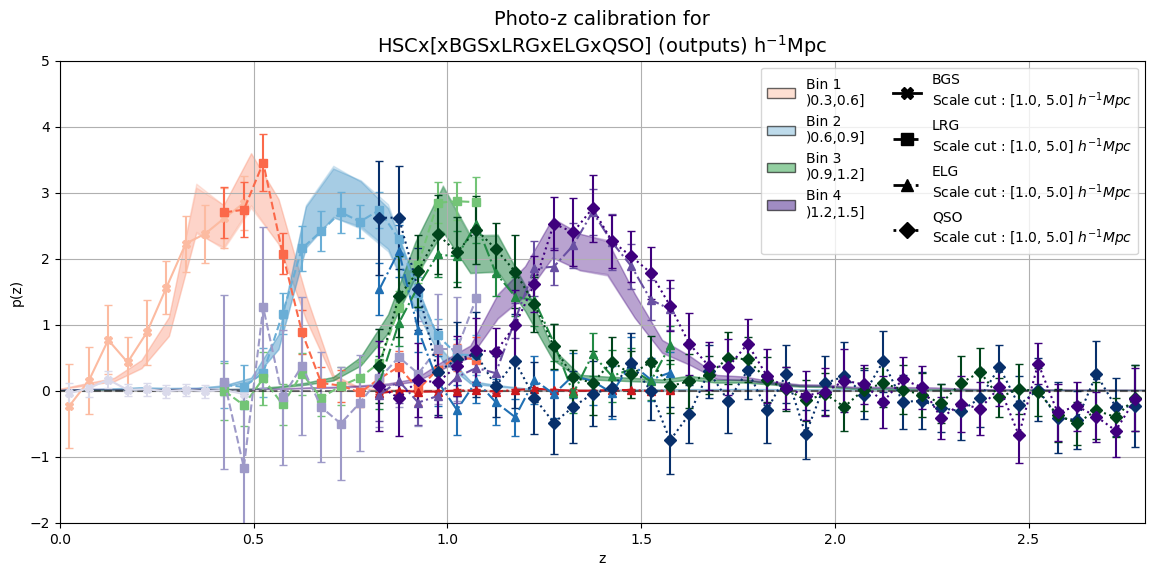

In [74]:
importlib.reload(inference)
ncurves = 0
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO'] #'LRG', 'ELGnotqso', 'QSO'] #'LRG', 'ELGnotqso', 'QSO']#'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

scale_cuts = [[1, 5]] # in Mpc/h #[[0.2, 2.5], [0.2, 2.5], [0.2, 5], [0.5, 5]]
if scale_cuts is not None and len(scale_cuts) == 1:
    scale_cuts = [scale_cuts[0] for _ in range(len(tracers))]

title = 'Photo-z calibration for\nHSCx['
for n in range(len(tracers)):
    t = tracers[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    print(zval)
    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[:, 0]
    mask_mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    ids_to_skip = []
    nz = []
    nz_err = []

    for tomo in range(1, 5):
        print(f"Computing n(z) for tracer {t} and tomo bin {tomo}")
        tomo_nz, tomo_nz_err = inference.full_npz_tomo(
                path_dictionary=path_dictionary,
                scale_cuts=scale_cuts[n],
                tracer=t,
                tomo_bin=tomo,
                #verbose=True,
                sigmaj_corrections=np.ones_like(sigmaj_corr),
                rebin=1,
                )
        nz.append(tomo_nz)
        nz_err.append(tomo_nz_err)
        
    area_ratio = []

    for outlier_idx in range(4):
        if max(range_tracer[0], bins_hsc[outlier_idx]) > min(range_tracer[1], bins_hsc[outlier_idx+1]):
            ids_to_skip.append(outlier_idx)

    for dnnz_idx in range(4):
        ncurves += 1

        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
        area_ratio.append(simpson(np.percentile(dnnz, 50, axis=0)[mask], x=mask_mids))

        if dnnz_idx in ids_to_skip:
            continue
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
            alpha=0.2
            )
        
    for j in range(4):
        if j in ids_to_skip and t=='QSO':
            continue
        mask = ~np.isnan(nz[j])
        normalization = simpson(nz[j][mask], x=zval[mask])/area_ratio[j]
        if normalization > 0:
            ax.errorbar(
                x=zval[mask], 
                y=nz[j][mask]/normalization,
                yerr=nz_err[j][mask]/normalization, 
                capsize=3,
                marker=markers[n], 
                linestyle=linestyles[n],
                markersize=6,   
                alpha=1,
                color=colormaps[j]((n+1)/4),
                )
        
    title+= f'x{tracer_trad[tracers[n]]}'
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in range(1, len(bins_hsc)):
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=tracer_trad[tracer] + f'\nScale cut : [{scale_cuts[i][0]:.1f}, {scale_cuts[i][1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.8)
ax.set_ylim(-2, 5)

### Calibration and parametrization
-----------------------------------



In [235]:
nz_per_tracer = {}
scale_cuts = [[0.2, 3]]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
if scale_cuts is not None and len(scale_cuts) == 1:
    scale_cuts = [scale_cuts[0] for _ in range(len(tracers))]

for ind_t, tracer in enumerate(tracers):
    nz_per_tracer[tracer] = {}
    for tomo in range(1, 5): 
        print(f"Computing n(z) for tracer {tracer} and tomo bin {tomo}")
        # this will save the npz file in the path_dictionary1
        meas = inference.full_npz_tomo(
            path_dictionary=path_dictionary,
            scale_cuts=scale_cuts[ind_t],
            tracer=tracer,
            tomo_bin=tomo,
            sigmaj_corrections=np.ones_like(sigmaj_corr),
            verbose=True,
        )
        nz_per_tracer[tracer][tomo] = meas

Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Computing n(z) for tracer LRG and tomo bin 1
Computing n(z) for tracer LRG and tomo bin 2
Computing n(z) for tracer LRG and tomo bin 3
Computing n(z) for tracer LRG and tomo bin 4
Computing n(z) for tracer ELGnotqso and tomo bin 1
Computing n(z) for tracer ELGnotqso and tomo bin 2
Computing n(z) for tracer ELGnotqso and tomo bin 3
Computing n(z) for tracer ELGnotqso and tomo bin 4
Computing n(z) for tracer QSO and tomo bin 1
Computing n(z) for tracer QSO and tomo bin 2
Computing n(z) for tracer QSO and tomo bin 3
Computing n(z) for tracer QSO and tomo bin 4


In [279]:
importlib.reload(cal)
nz, nzerr, z = cal.calibrate_tomo_bin(
    path_dictionary=path_dictionary,
    nzs_per_tracer=nz_per_tracer,
    tomo_bin=3,
    only_nz=True,
)

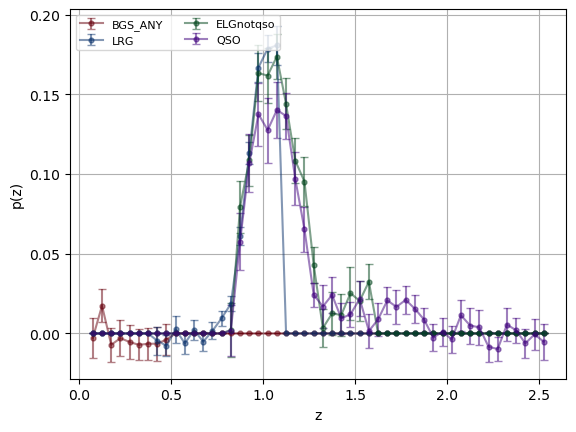

In [280]:
for tracer in nz_per_tracer.keys():
    mask = ~np.isnan(nz[tracer])
    plt.errorbar(
        z[mask], 
        nz[tracer][mask], 
        nzerr[tracer][mask], 
        marker='o', 
        markersize=3.5, 
        linestyle='-',  
        alpha=0.5,
        label=tracer,
        color=colormaps[tracers.index(tracer)]((ind_t+1)/4),
        capsize=3
    )
plt.xlabel('z')
plt.ylabel('p(z)')
plt.grid()
plt.legend(fontsize=8, ncols=2, loc='upper left')

In [276]:
importlib.reload(cal)
calresult = cal.calibrate_tomo_bin(
    path_dictionary=path_dictionary,
    nzs_per_tracer=nz_per_tracer,
    tomo_bin=3,
    only_nz=False,
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 21.98415765256091
            Iterations: 162
            Function evaluations: 9021
            Gradient evaluations: 162


In [277]:
calresult.x[len(z):]

array([-0.02015219,  0.07526406,  0.07231786,  0.06035635])

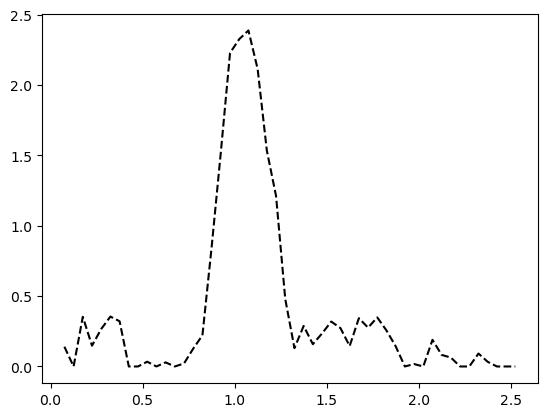

In [278]:
plt.plot(z, calresult.x[:len(z)], label='calibrated p(z)', color='black', linestyle='--')

### Bin shifting
-----------------

Let's now shift the bins by $\frac{\Delta z}{2}$ and see if we can recover a similar signal.

In [17]:
path_dictionary1 = {
    'HSC' : ROOT / 'current4' / f'auto_{desc}_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / 'current4' / f'auto_{desc}_NGC',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / 'current4' / f'cross_{desc}',
}
path_dictionary2 = {
    'HSC' : ROOT / 'current4' / f'auto_{desc}_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / 'current4_offset' / f'auto_{desc}_NGC',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / 'current4_offset' / f'cross_{desc}',
}

for k, v in {**path_dictionary1, **path_dictionary2}.items():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."

Tracer QSO
zval : [0.975 1.125 1.275 1.425 1.575 1.725 1.875 2.025 2.175 2.325 2.475 2.625
 2.775]
zval_offset : [0.9  1.05 1.2  1.35 1.5  1.65 1.8  1.95 2.1  2.25 2.4  2.55 2.7 ]
Computing n(z) for tracer QSO and tomo bin 1
Computing n(z) for tracer QSO and tomo bin 2
Computing n(z) for tracer QSO and tomo bin 3
Computing n(z) for tracer QSO and tomo bin 4
Tracer LRG
zval : [0.425 0.475 0.525 0.575 0.625 0.675 0.725 0.775 0.825 0.875 0.925 0.975
 1.025 1.075]
zval_offset : [0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05]
Computing n(z) for tracer LRG and tomo bin 1
Computing n(z) for tracer LRG and tomo bin 2
Computing n(z) for tracer LRG and tomo bin 3
Computing n(z) for tracer LRG and tomo bin 4


(-2.0, 4.0)

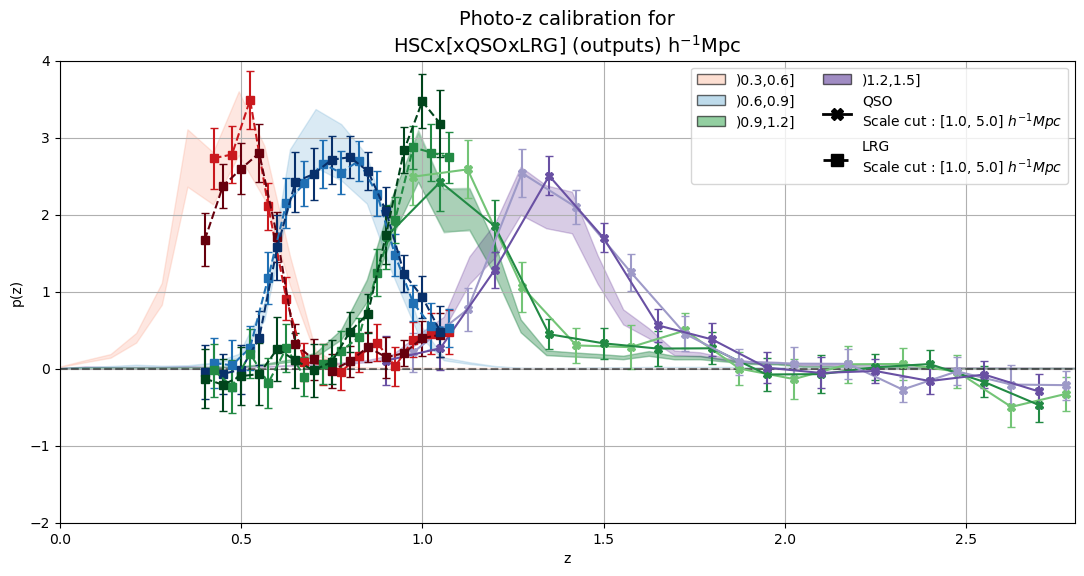

In [18]:
## shifting bins
importlib.reload(inference)

ncurves = 0
tracers = ['QSO', 'LRG'] #'LRG', 'ELGnotqso', 'QSO'] #'LRG', 'ELGnotqso', 'QSO']#'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))
fig.subplots_adjust(right=0.85) 

scale_cuts = [[1, 5]] # in Mpc/h #[[0.2, 2.5], [0.2, 2.5], [0.2, 5], [0.5, 5]]
if scale_cuts is not None and len(scale_cuts) == 1:
    scale_cuts = [scale_cuts[0] for _ in range(len(tracers))]

title = 'Photo-z calibration for\nHSCx['
for n in range(len(tracers)):
    t = tracers[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary1['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    bins_tracer_offset = cf.CorrFileReader(
        path_dictionary2['DESI_NGC'],
        ).get_bins(t)
    zval_offset = bins_tracer_offset[:-1] + np.diff(bins_tracer_offset) / 2
    print(f"zval : {zval}")
    print(f"zval_offset : {zval_offset}")

    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mask_offset = (tomo_bin_dnnz[:, 0] >= min(bins_tracer_offset)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer_offset))
    mids = tomo_bin_dnnz[:, 0]

    mask_mids = tomo_bin_dnnz[mask, 0]
    mask_mids_offset = tomo_bin_dnnz[mask_offset, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    ids_to_skip = []
    nz = []
    nz_err = []
    nz_offset = []
    nz_offset_err = []

    for tomo in range(1, 5):
        print(f"Computing n(z) for tracer {t} and tomo bin {tomo}")
        kwargs = {
            'scale_cuts' : scale_cuts[n],
            'tracer' : t,
            'tomo_bin' : tomo,
            'sigmaj_corrections' : np.ones_like(sigmaj_corr),
            'verbose' : False,
            'rebin' : 1
        }
        tomo_nz, tomo_nz_err = inference.full_npz_tomo(
            path_dictionary=path_dictionary1,
            **kwargs,
            )
        tomo_nz_offset, tomo_nz_offset_err = inference.full_npz_tomo(
            path_dictionary=path_dictionary2,
            **kwargs,
            )
        
        nz.append(tomo_nz)
        nz_err.append(tomo_nz_err)
        nz_offset.append(tomo_nz_offset)
        nz_offset_err.append(tomo_nz_offset_err)
        
    area_ratio = []
    area_ratio_offset = []

    for outlier_idx in range(4):
        if max(range_tracer[0], bins_hsc[outlier_idx]) > min(range_tracer[1], bins_hsc[outlier_idx+1]):
            ids_to_skip.append(outlier_idx)

    for dnnz_idx in range(4):
        ncurves += 1

        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
        area_ratio.append(simpson(np.percentile(dnnz, 50, axis=0)[mask], x=mask_mids))
        area_ratio_offset.append(simpson(np.percentile(dnnz, 50, axis=0)[mask_offset], x=mask_mids_offset))

        if dnnz_idx in ids_to_skip:
            continue
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
            alpha=0.2
            )
        
    for j in range(4):
        if j in ids_to_skip:
            continue
        normalization = simpson(nz[j], x=zval)/area_ratio[j]
        normalization_offset = simpson(nz_offset[j], x=zval_offset)/area_ratio_offset[j]

        if normalization > 0:
            ax.errorbar(
                x=zval, 
                y=nz[j]/normalization,
                yerr=nz_err[j]/normalization, 
                capsize=3,
                marker=markers[n], 
                linestyle=linestyles[n],
                markersize=6,   
                alpha=1,
                color=colormaps[j]((n+2)/4),
                )
            ax.errorbar(
                x=zval_offset, 
                y=nz_offset[j]/normalization_offset,
                yerr=nz_offset_err[j]/normalization_offset, 
                capsize=3,
                marker=markers[n], 
                linestyle=linestyles[n],
                markersize=6,   
                alpha=1,
                color=colormaps[j]((n+3)/4),
                )
        else: 
            raise ValueError(f"Normalization is zero for tracer {t} and tomo bin {j+1}.")
        
    title+= f'x{tracers[n]}'
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in range(1, len(bins_hsc)):
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=tracer_trad[tracer] + f'\nScale cut : [{scale_cuts[i][0]:.1f}, {scale_cuts[i][1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.8)
ax.set_ylim(-2, 4)

- Problème de normalisation (fit avec contraintes)
- Première version des slides 
- Gaussian Mixture avec David (ou peut-être spline)
- Joint constraints
- covariance on errors to smooth out with shifted-bins method

### Normalization calibration
-----------------------------
Basic idea is to match on overlapping bins, so that the amplitude of the cross correlations match. NB : how to recover the errors here ?

In [232]:
nz_per_tracer = {}
scale_cuts = [[1, 5]]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
if scale_cuts is not None and len(scale_cuts) == 1:
    scale_cuts = [scale_cuts[0] for _ in range(len(tracers))]

for ind_t, tracer in enumerate(tracers):
    nz_per_tracer[tracer] = {}
    for tomo in range(1, 5): 
        print(f"Computing n(z) for tracer {tracer} and tomo bin {tomo}")
        # this will save the npz file in the path_dictionary1
        meas = inference.full_npz_tomo(
            path_dictionary=path_dictionary,
            scale_cuts=scale_cuts[ind_t],
            tracer=tracer,
            tomo_bin=tomo,
            sigmaj_corrections=np.ones_like(sigmaj_corr),
            verbose=True,
        )
        nz_per_tracer[tracer][tomo] = meas

Computing n(z) for tracer BGS_ANY and tomo bin 1
Computing n(z) for tracer BGS_ANY and tomo bin 2
Computing n(z) for tracer BGS_ANY and tomo bin 3
Computing n(z) for tracer BGS_ANY and tomo bin 4
Computing n(z) for tracer LRG and tomo bin 1
Computing n(z) for tracer LRG and tomo bin 2
Computing n(z) for tracer LRG and tomo bin 3
Computing n(z) for tracer LRG and tomo bin 4
Computing n(z) for tracer ELGnotqso and tomo bin 1
Computing n(z) for tracer ELGnotqso and tomo bin 2
Computing n(z) for tracer ELGnotqso and tomo bin 3
Computing n(z) for tracer ELGnotqso and tomo bin 4
Computing n(z) for tracer QSO and tomo bin 1
Computing n(z) for tracer QSO and tomo bin 2
Computing n(z) for tracer QSO and tomo bin 3
Computing n(z) for tracer QSO and tomo bin 4


Bin 1


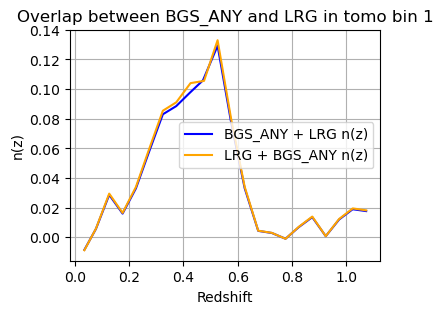

Bin 2


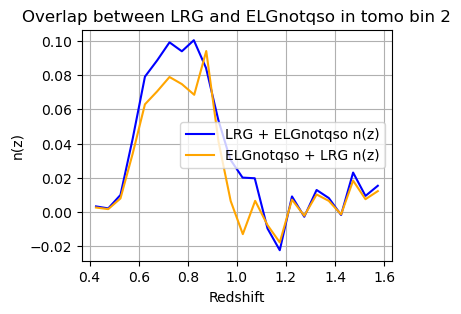

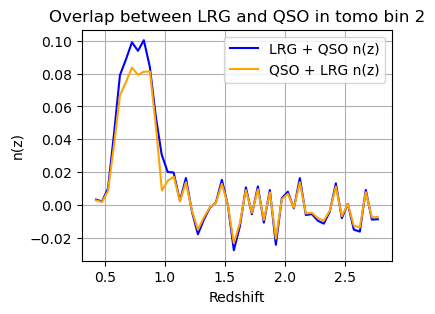

Bin 3


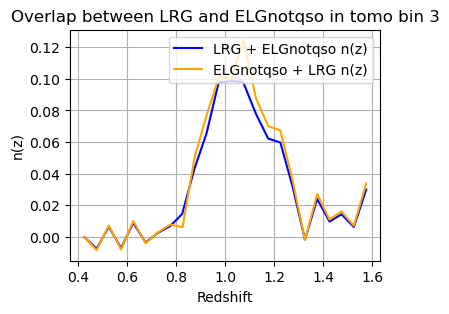

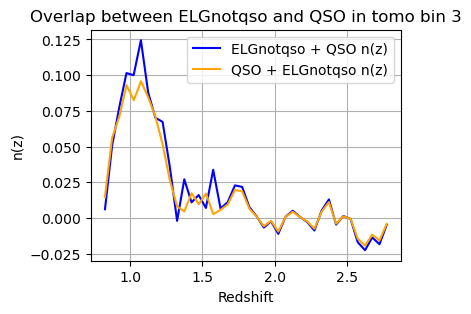

Bin 4


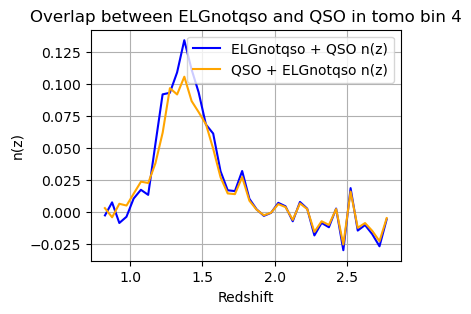

In [233]:
importlib.reload(comb)
norm_per_tracer = comb.get_norm_per_tracer(path_dictionary, nz_per_tracer, method='standard')

Tracer BGS_ANY
zval : [0.025 0.075 0.125 0.175 0.225 0.275 0.325 0.375 0.425 0.475]
Tracer LRG
zval : [0.425 0.475 0.525 0.575 0.625 0.675 0.725 0.775 0.825 0.875 0.925 0.975
 1.025 1.075]
Tracer ELGnotqso
zval : [0.825 0.875 0.925 0.975 1.025 1.075 1.125 1.175 1.225 1.275 1.325 1.375
 1.425 1.475 1.525 1.575]
Tracer QSO
zval : [0.825 0.875 0.925 0.975 1.025 1.075 1.125 1.175 1.225 1.275 1.325 1.375
 1.425 1.475 1.525 1.575 1.625 1.675 1.725 1.775 1.825 1.875 1.925 1.975
 2.025 2.075 2.125 2.175 2.225 2.275 2.325 2.375 2.425 2.475 2.525 2.575
 2.625 2.675 2.725 2.775]


(-1.0, 4.0)

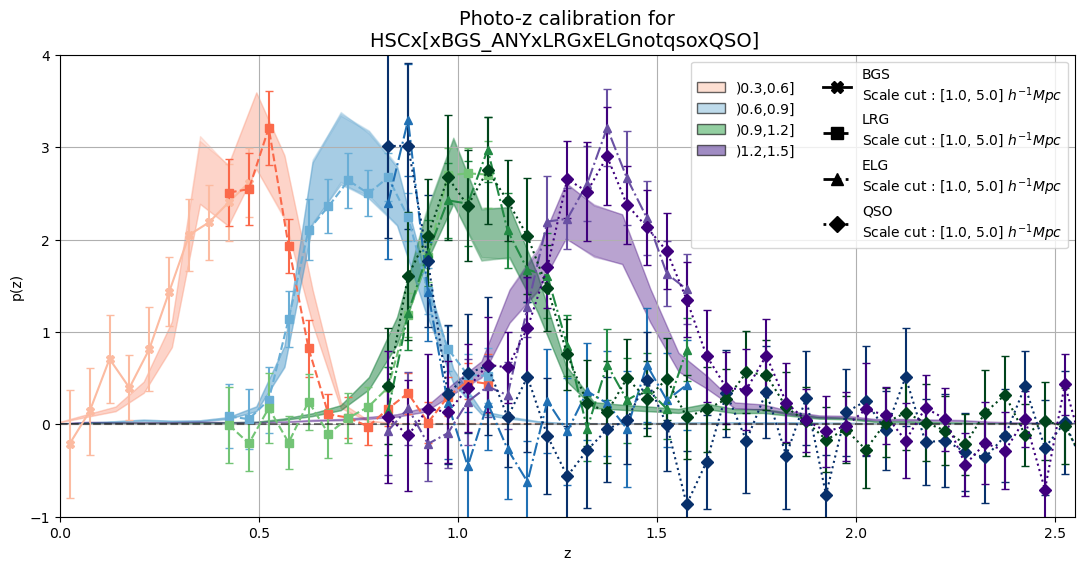

In [234]:
# correcting for normalization based on joint overlaps
importlib.reload(inference)
importlib.reload(comb)

ncurves = 0
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

# tomographic binning...
bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))
fig.subplots_adjust(right=0.85) 

title = 'Photo-z calibration for\nHSCx['
for n in range(len(tracers)):
    t = tracers[n]
    print(f"Tracer {t}")
    bins_tracer = cf.CorrFileReader(
        path_dictionary['DESI_NGC'],
        ).get_bins(t)
    zval = bins_tracer[:-1] + np.diff(bins_tracer) / 2
    print(f"zval : {zval}")

    range_tracer = [bins_tracer[0], bins_tracer[-1]]
    mask = (tomo_bin_dnnz[:, 0] >= min(bins_tracer)) & (tomo_bin_dnnz[:, 0] <= max(bins_tracer))
    mids = tomo_bin_dnnz[:, 0]

    mask_mids = tomo_bin_dnnz[mask, 0]

    dnnz_list = []
    mu_list = []
    cov_list = []

    ids_to_skip = []
    nz = []
    nz_err = []
    nz_offset = []
    nz_offset_err = []

    for outlier_idx in range(4):
        if max(range_tracer[0], bins_hsc[outlier_idx]) > min(range_tracer[1], bins_hsc[outlier_idx+1]):
            ids_to_skip.append(outlier_idx)

    for dnnz_idx in range(4):
        ncurves += 1

        dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
    
        if dnnz_idx in ids_to_skip:
            continue
        ax.fill_between(
            mids, 
            np.percentile(dnnz, 16, axis=0), 
            np.percentile(dnnz, 84, axis=0), 
            color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
            alpha=0.2
            )
        
    for j in range(4):
        if j in ids_to_skip:
            continue

        mask = ~np.isnan(nz_per_tracer[t][j+1][0])
        ax.errorbar(
            x=zval[mask], 
            y=nz_per_tracer[t][j+1][0][mask]*norm_per_tracer[t][j+1],
            yerr=nz_per_tracer[t][j+1][1][mask]*norm_per_tracer[t][j+1],
            capsize=3,
            marker=markers[n], 
            linestyle=linestyles[n],
            markersize=6,   
            alpha=1,
            color=colormaps[j]((n+1)/4),
            )
        
    title+= f'x{tracers[n]}'
        
title+=f'] '
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in range(1, len(bins_hsc)):
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=tracer_trad[tracer] + f'\nScale cut : [{scale_cuts[i][0]:.1f}, {scale_cuts[i][1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.55)
ax.set_ylim(-1, 4)

## $r_{cc}$ analysis on simulations

------------------------------------

In [58]:
importlib.reload(inference)
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
desc = 'j64_ns256'
path_dictionary = {
    'HSC' : ROOT / 'sims2' / f'auto_{desc}', #quasar spacing bla bla bla
    'DESI_NGC' : ROOT / 'sims2' / f'auto_{desc}',
    'DESI_SGC' : None, #ROOT / f'autos_{desc}_SGC',
    'DESIxHSC' : ROOT / 'sims2' / f'cross_{desc}',
}
for v in path_dictionary.values():
    if v is not None:
        assert Path(v).is_dir(), f"Path {v} does not exist as a directory. Please check the path."
        
def rebin_edges(edges, factor=2):
    num_bins = len(edges) - 1
    num_new_bins = num_bins // factor
    new_edges = edges[::factor]

    # Include the last edge of the last full bin
    if len(new_edges) != num_new_bins + 1:
        new_edges = np.append(new_edges, edges[factor * num_new_bins])

    return new_edges

In [184]:
importlib.reload(inference)
scale_cuts = [0, 200]
tracer_rcc1 = 'BGS_ANY'
tracer_rcc2 = 'HSC'
rebin = 2
frcc = inference.full_rcc(
    path_dictionary=path_dictionary,
    tracer1=tracer_rcc1,
    tracer2=tracer_rcc2,
    scale_cuts=scale_cuts,
    rebin=rebin
    )

tracer1_redshift : [0.  0.1 0.2 0.3 0.4 0.5], t1_to_t2_bin_indices : [1 2 3 4 5]
tracer2_redshift : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ], t2_to_t1_bin_indices : [1 2 3 4 5]
bin_index1, bin_index2 : 1, 1
wpp : bin_index : 1, zloc : 0.05
bin_index1, bin_index2 : 2, 2
wpp : bin_index : 2, zloc : 0.15000000000000002
bin_index1, bin_index2 : 3, 3
wpp : bin_index : 3, zloc : 0.25
bin_index1, bin_index2 : 4, 4
wpp : bin_index : 4, zloc : 0.35000000000000003
bin_index1, bin_index2 : 5, 5
wpp : bin_index : 5, zloc : 0.45


In [185]:
frcc

[array([0.99439567, 0.98131719, 0.97724632, 0.9747589 , 0.97608732,
        0.9580918 , 0.94134629, 0.9123165 , 0.87288304, 0.79522254]),
 array([1.05735191, 1.02074547, 1.00654572, 1.00899383, 1.00629281,
        1.0110735 , 1.01267426, 1.0159397 , 1.01122395, 1.01382119]),
 array([1.11889579, 1.04500296, 0.98813142, 0.98139597, 0.96112266,
        0.93795795, 0.91129739, 0.90221617, 0.87938495, 0.85262587]),
 array([1.14533406, 1.11606835, 1.04005958, 1.02400716, 0.99362966,
        0.98537809, 0.96323277, 0.96080983, 0.93857331, 0.91486683]),
 array([1.30946842, 1.33545976, 1.2503603 , 1.12094607, 1.03680782,
        0.99149934, 0.94279297, 0.92930642, 0.94489643, 0.92794751])]

rp_sep : [ 0.08        0.13895814  0.24136705  0.41924896  0.72822568  1.26491106
  2.19712109  3.81634821  6.62890803 11.51425902 20.        ]
bins_t1 : [0.  0.1 0.2 0.3 0.4 0.5]
bins_t2 : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]
zval : [0.05 0.15 0.25 0.35 0.45]


Text(0.5, 1.0, '$r_{cc}$ for BGS_ANYxHSC')

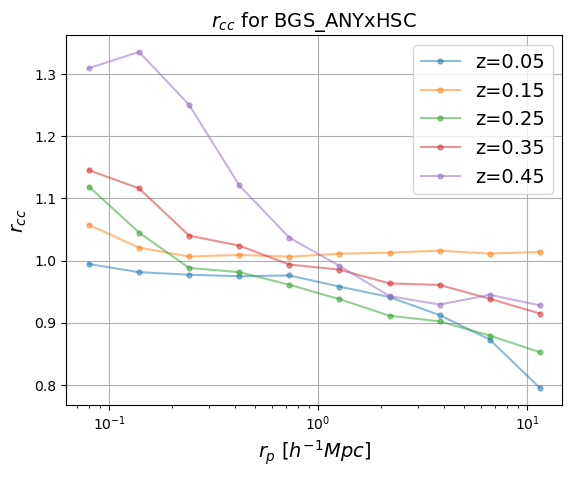

In [186]:
reader = cf.CorrFileReader(
    path_dictionary['DESI_NGC'],
    )
rp_sep = rebin_edges(reader.get_bins('rp'), factor=rebin)
print(f"rp_sep : {rp_sep}")

bins_t1 = np.array(reader.get_bins(tracer_rcc1))
bins_t2 = np.array(reader.get_bins(tracer_rcc2))
print(f"bins_t1 : {bins_t1}")
print(f"bins_t2 : {bins_t2}")

zval_bins = []
for val in bins_t2:
    if np.any(np.isclose(val, bins_t1, atol=0.02)):
        zval_bins.append(val)
zval = zval_bins[:-1] + np.diff(zval_bins) / 2
print(f"zval : {zval}")

for i, r in enumerate(frcc):
    #scale = ct.arcsec2hMpc(sep*3600, zval[i])
    ## for now at LRG redshifts these are the same since minimum scale is > 0.1
    scale = rp_sep[:len(r)]
    plt.plot(scale, r, marker='o', markersize=3.5, linestyle='-', alpha=0.5, label=f'z={zval[i]:.2f}')
plt.xscale('log')
plt.xlabel(r'$r_p$ [$h^{-1}Mpc$]', fontsize=14)
plt.ylabel(r'$r_{cc}$', fontsize=14)
plt.grid()
plt.legend(loc='upper right', fontsize=14)
plt.title(r'$r_{cc}$' + f' for {tracer_rcc1}x{tracer_rcc2}', fontsize=14)

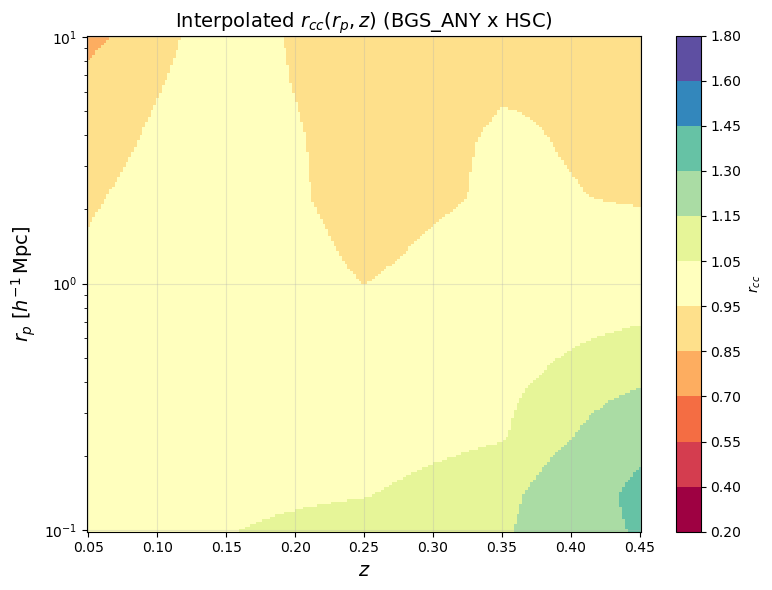

In [187]:
rcc_interp = []
scale_matrix = []

common_scale = np.logspace(-1, 1, 100)  # 0.1 to 10 h⁻¹Mpc (adjust as needed)

for i, r in enumerate(frcc):
    interp = interp1d(scale, r, bounds_error=False, fill_value=np.nan)
    rcc_interp.append(interp(common_scale))

# rcc_interp: shape (n_z, n_common_scale)
# Interpolator expects (z, r_p) in order, so we flip axes
rcc_interp_func = RegularGridInterpolator(
    (zval[:len(frcc)], common_scale),
    rcc_interp,
    bounds_error=False,
    fill_value=np.nan
)

z_fine = np.linspace(min(zval[:len(frcc)]), max(zval[:len(frcc)]), 200)
r_fine = np.logspace(-1, 1, 200)
Z_fine, R_fine = np.meshgrid(z_fine, r_fine)

# Flatten for evaluation
points = np.stack([Z_fine.ravel(), R_fine.ravel()], axis=-1)
rcc_interp_smooth = rcc_interp_func(points).reshape(Z_fine.shape)

levels = [0.2, 0.4, 0.55, 0.7, 0.85, 0.95, 1.05, 1.15, 1.3, 1.45, 1.6, 1.8] #[0.2, 0.4, 0.5, 0.6, 0.75, 0.85, 0.95, 1.05, 1.2]  # 5 intervals = 6 boundaries
vcenter = 1.0

# Step 2: Use a diverging colormap with same number of color bins as level intervals
n_colors = len(levels) - 1
cmap_full = plt.get_cmap('Spectral', 256)  # fine-grained original colormap
colors = cmap_full(np.linspace(0, 1, 256))
i_center = np.argmin(np.abs(np.array(levels) - vcenter))
n_below = i_center
n_above = len(levels) - 1 - i_center
new_colors = cmap_full(np.linspace(0, 1, n_colors))
cmap = mcolors.ListedColormap(new_colors)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=cmap.N, clip=True)

plt.figure(figsize=(8, 6))
pc = plt.pcolormesh(Z_fine, R_fine, rcc_interp_smooth, cmap=cmap, norm=norm, shading='auto')
plt.yscale('log')
plt.xlabel(r'$z$', fontsize=14)
plt.ylabel(r'$r_p$ [$h^{-1}\,\mathrm{Mpc}$]', fontsize=14)
plt.title(r'Interpolated $r_{cc}(r_p, z)$' + f' ({tracer_rcc1} x {tracer_rcc2})', fontsize=14)

cbar = plt.colorbar(pc, ticks=levels, label=r'$r_{cc}$')
cbar.ax.set_yticklabels([f"{lvl:.2f}" for lvl in levels])

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()